
Financial Report Disclosure Tone Analyzer

This notebook analyzes the textual sections of a company's financial reports
to determine the overall tone (positive, negative, neutral) using Generative AI
capabilities learned in the 5-day Gen AI Intensive Course with Google.

Project for the Gen AI Intensive Course with Google (March 31 - April 4, 2025)

Author: Izuardo Zulkarnain
Date: April 8, 2025





 1. Introduction and Use Case

 **Use Case:** This project aims to analyze the disclosure tone in company financial reports, specifically focusing on sections like the Management's Discussion and Analysis (MD&A). Understanding the sentiment expressed in these reports can provide valuable insights into the company's outlook, potential risks, and overall communication strategy. This analysis can be beneficial for investors, analysts, and other stakeholders.

 **Problem:** Manually analyzing the tone of lengthy financial reports is time-consuming and subjective. Generative AI offers powerful tools to automate this process and provide more objective and scalable insights.

 1.Gen AI Capabilities Demonstrated:
 This notebook will demonstrate the following Gen AI capabilities:
  Document Understanding (for parsing the reports and identifying sections)
  Sentiment Analysis using Few-Shot Prompting with a Large Language Model
  Embeddings/Vector Search (for quantifying tone and identifying related sentiment-bearing words)
  Structured Output (for presenting results in JSON format)
  Gen AI Evaluation (for evaluating the tone analysis results)

2.Setup and Libraries


In [1]:
!pip install -Uq "google-genai==1.7.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.7/144.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.9/100.9 kB 5.2 MB/s eta 0:00:00


In [2]:
from google import genai
from google.genai import types

from IPython.display import Markdown, display

genai.__version__

'1.7.0'

In [3]:
# Install necessary libraries (if running in a clean environment)
# !pip install PyPDF2 sentence-transformers transformers
!pip install PyPDF2 sentence-transformers transformers

import os
import re
import json
import enum
from PyPDF2 import PdfReader  # For PDF extraction
from sentence_transformers import SentenceTransformer, util  # For embeddings
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification # For LLM
from google import genai
from google.genai import types
from kaggle_secrets import UserSecretsClient

# Get the API key
client = genai.Client(api_key=UserSecretsClient().get_secret("GOOGLE_API_KEY"))

# ## 3. Data Loading and Preprocessing

# **Important:**
# 1. **Download a financial report PDF and upload it to your Kaggle Notebook.**
#    You can do this by clicking on the "+ Add Data" button in the notebook sidebar.
# 2. **Replace the placeholder path below with the actual path to your uploaded file.**


report_file_path = "/kaggle/input/shell-report/sample2.pdf" 

def extract_text_from_pdf(pdf_path):
    """Extracts text content from a PDF file."""
    text = ""
    try:
        with open(pdf_path, 'rb') as file:
            reader = PdfReader(file)
            for page_num in range(len(reader.pages)):
                page = reader.pages[page_num]
                text += page.extract_text()
    except Exception as e:
        print(f"Error reading PDF: {e}")
    return text

def preprocess_text(text):
    """Basic text cleaning (remove extra whitespace, etc.)."""
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Load and preprocess the financial report
report_text = extract_text_from_pdf(report_file_path)
processed_text = preprocess_text(report_text)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 4.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.2 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 32.8 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found exi

2025-04-14 16:02:08.128753: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744646528.403792      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744646528.478061      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
processed_text

In [5]:
import re

def extract_sections_regex(text, section_mapping):
    """
    Extracts sections from text using regular expressions.

    Args:
        text (str): The text of the document.
        section_mapping (dict): A dictionary mapping section names to regex patterns.

    Returns:
        dict: A dictionary of extracted sections.
    """

    sections = {}
    for section_name, regex_pattern in section_mapping.items():
        matches = list(re.finditer(regex_pattern, text, re.IGNORECASE | re.MULTILINE))  # Case-insensitive, multiline

        for i, match in enumerate(matches):
            start = match.start()
            end = len(text)
            if i + 1 < len(matches):
                end = matches[i + 1].start()
            sections.setdefault(section_name, []).append(text[start:end].strip())  # Handle multiple occurrences

    return sections

# Example Usage:
section_mapping_regex = {
    "MD&A": r"Management's Discussion and Analysis",
    "Risk Factors": r"Risk\s+Factors",  
    "Financial Statements": r"Financial\s+Statements",
    "Business": r"Item\s+1\.\s+Business",  
}

sections_regex = extract_sections_regex(processed_text, section_mapping_regex)

print("Extracted Sections (Regex):", list(sections_regex.keys()))
for name, contents in sections_regex.items():
    print(f"\n--- Content of {name} (First 200 chars) ---")
    for content in contents:
        print(content[:200] + "...")

Extracted Sections (Regex): ['Risk Factors', 'Financial Statements']

--- Content of Risk Factors (First 200 chars) ---
risk factors 145 Principal decisions & stakeholders (Section 172(1) statement) Governance 150 Introduction from the Chair 152 The Board of Shell plc 157 Executive Committee 159 Governance framework 16...
Risk factors 145 Principal decisions & stakeholders Section 172(1) statement 1 Shell Annual Report and Accounts 2024In 2024, we continued to do what Shell does best, connecting energy and people. In t...
Risk factors" on page 139, Note 24 and Note 26 to the "Consolidated Financial Statements" on pages 290-296 and 298-304.Strategic Report | Performance in the year | Generating shareholder value 24 Shel...
Risk factors" on page 135. We prepare an annual financial plan that tests different scenarios, and their impact on prices, on our businesses and organisation as a whole. These scenarios help us determ...
Risk factors" on page 135 and Note 12 to the "Consolidated Finan

In [ ]:
sections_regex

In [ ]:
# ## 4. Tone Analysis Implementation

# ### 4.1. Sentiment Analysis using Few-Shot Prompting with a Large Language Model

import time  # Import the time module

# Define few-shot examples for financial tone analysis
few_shot_examples = [
    {"text": "The company achieved record profits and expanded its market share, demonstrating strong growth.", "tone": "Positive", "explanation": "Keywords like 'record profits' and 'strong growth' indicate a positive outlook."},
    {"text": "There are significant risks associated with the new regulations, which could negatively impact our future earnings.", "tone": "Negative", "explanation": "Phrases like 'significant risks' and 'negatively impact' suggest a negative tone."},
    {"text": "The financial results were in line with expectations, with revenue remaining stable compared to the previous year.", "tone": "Neutral", "explanation": "Statements of fact without strong positive or negative connotations indicate a neutral tone."},
    {"text": "Despite challenges in the global economy, we remain optimistic about our long-term growth prospects.", "tone": "Positive", "explanation": "While acknowledging 'challenges,' the overall sentiment is positive due to 'optimistic' and 'growth prospects.'"},
    {"text": "Sales declined sharply by 20% due to unforeseen circumstances, leading to a substantial loss for the quarter.", "tone": "Negative", "explanation": "'Declined sharply' and 'substantial loss' strongly convey a negative tone."},
    {"text": "EBITDA increased by 15% year-over-year, reflecting improved operational efficiency and cost management.", "tone": "Positive", "explanation": "A significant increase in a key metric like EBITDA is viewed positively in finance."},
    {"text": "The company faces increasing competitive pressure, which could negatively impact future profitability and market share.", "tone": "Negative", "explanation": "This highlights a threat to the company's financial performance."},
    {"text": "Capital expenditures were maintained at previous levels, with ongoing investments in research and development.", "tone": "Neutral", "explanation": "This is a statement of fact about investment activity, neither strongly positive nor negative."},
    {"text": "While revenue growth has slowed compared to previous periods, we anticipate a rebound in the next fiscal year.", "tone": "Mixed", "explanation": "This contains both negative ('slowed growth') and positive ('anticipate a rebound') elements."},
    {"text": "Impairment charges related to goodwill amounted to $10 million, reflecting a reassessment of asset values.", "tone": "Negative", "explanation": "Impairment charges are generally seen as negative as they indicate a reduction in asset value."},
    {"text": "Management believes that the current accounting policies accurately reflect the company's financial position and results of operations.", "tone": "Neutral", "explanation": "This is a statement about the accuracy of accounting practices."},
    {"text": "The company's liquidity position is strong, providing flexibility for strategic acquisitions and shareholder returns.", "tone": "Positive", "explanation": "Strong liquidity is a positive indicator of financial health."},
    {"text": "The ongoing litigation could have a material adverse effect on our financial results and reputation.", "tone": "Negative", "explanation": "Litigation with a 'material adverse effect' is a significant negative."},
    {"text": "We are cautiously optimistic about the prospects for our new product line, pending regulatory approvals.", "tone": "Positive", "explanation": "Despite the caution, the overall sentiment is positive due to 'optimistic.'"},
    {"text": "The company's debt burden is significant and may limit its ability to raise additional capital for expansion.", "tone": "Negative", "explanation": "High debt is a negative factor that can hinder growth."},
    {"text": "Operating expenses were slightly higher than anticipated due to increased marketing spend.", "tone": "Neutral", "explanation": "Increased expenses can be negative, but if due to marketing, it might have future positive implications."},
    {"text": "The successful integration of the acquired company has created significant synergies and cost savings.", "tone": "Positive", "explanation": "Synergies and cost savings are positive outcomes of an acquisition."},
    {"text": "Increased volatility in the market poses a risk to our investment portfolio and could impact returns.", "tone": "Negative", "explanation": "Volatility and risk to investments are negative factors."},
    {"text": "The company's inventory turnover ratio improved, indicating efficient inventory management and sales.", "tone": "Positive", "explanation": "Improved inventory turnover is a positive sign of operational efficiency."},
    {"text": "There is a risk that the company may not be able to meet its debt obligations if economic conditions worsen.", "tone": "Negative", "explanation": "The risk of not meeting debt obligations is a serious concern."},
]

# Build the few-shot prompt
few_shot_prompt = "Analyze the tone of the following financial text. Classify it as Positive, Negative, or Neutral. Provide a brief explanation for your classification.\n\n"
for example in few_shot_examples:
    few_shot_prompt += f"Text: \"{example['text']}\"\nTone: {example['tone']}\nExplanation: {example['explanation']}\n\n"
few_shot_prompt += "Text: \"{text_to_analyze}\"\nTone: "

def analyze_sentiment_few_shot(text_snippet, llm_client, model_name='gemini-2.0-flash', max_length=512, delay=0.2):  # Added delay
    """
    Analyzes sentiment using few-shot prompting with a Large Language Model, with rate limiting.

    Args:
        text_snippet (str): The text to analyze.
        llm_client: The client for interacting with the LLM.
        model_name (str, optional): The name of the LLM to use. Defaults to 'gemini-2.0-flash'.
        max_length (int, optional): The maximum length of the input text. Defaults to 512.
        delay (float, optional): Seconds to wait before making the API call. Defaults to 0.2.

    Returns:
        str: The sentiment analysis result, or "N/A" on error.
    """

    time.sleep(delay)  # Simple rate limiting
    prompt = few_shot_prompt.format(text_to_analyze=text_snippet[:max_length])  # Limit input length
    try:
        response = llm_client.models.generate_content(model=model_name, contents=prompt)
        return response.text.strip()
    except Exception as e:
        print(f"Error analyzing sentiment: {e}")
        return "N/A"  

sentiment_results = {}
for section_name, text_or_texts in sections_regex.items():  
    if isinstance(text_or_texts, list):
        
        sentiment_results[section_name] = [
            analyze_sentiment_few_shot(text, client) for text in text_or_texts
        ]
    else:
        sentiment_results[section_name] = analyze_sentiment_few_shot(text_or_texts, client)

print("\nSentiment Analysis Results (using Few-Shot Prompting):")
print(json.dumps(sentiment_results, indent=4))

In [13]:
sentiment_results

{'Risk Factors': ['Neutral\nExplanation: This is a table of contents-like section of a report, listing topics and page numbers. It presents factual information without expressing any positive or negative sentiment.',
  "Neutral\nExplanation: The text describes the company's activities and customer base without expressing strong positive or negative sentiments about the company's financial health or future prospects.",
  "Neutral\nExplanation: This excerpt presents factual financial data (capitalization table, debt figures) and refers to risk factors documented elsewhere in the report. While risk factors themselves can be negative, the act of referencing them in this context is neutral. The numbers presented are simply facts, and there's no subjective language indicating positive or negative sentiment. There is a decrease in equity and debt but that doesn't automatically denote a negative tone as it is common during operations.",
  "Neutral\nExplanation: This text focuses on risk assess

In [14]:

def clean_sentiment_results(sentiment_results):
    """
    Cleans the sentiment analysis results by removing "N/A" entries.

    Args:
        sentiment_results (dict): The dictionary of sentiment analysis results.

    Returns:
        dict: A new dictionary with "N/A" entries removed.
    """
    cleaned_results = {}
    for section, results in sentiment_results.items():
        if isinstance(results, list):
            cleaned_results[section] = [res for res in results if res != "N/A"]
        elif results != "N/A":
            cleaned_results[section] = results
    return cleaned_results

def summarize_section_sentiment(section_name, sentiment_results, llm_client, model_name='gemini-2.0-flash', max_summary_length=200):
    """
    Generates a comprehensive yet based on data summary (give evidence or source of claim) for a section based on its sentiment analysis results.

    Args:
        section_name (str): The name of the section.
        sentiment_results (dict): The cleaned dictionary of sentiment analysis results.
        llm_client: The client for interacting with the LLM.
        model_name (str, optional): The name of the LLM to use. Defaults to 'gemini-2.0-flash'.
        max_summary_length (int, optional): The maximum length of the summary. Defaults to 200.

    Returns:
        str: A summary of the section's sentiment, or None if no valid results.
    """

    results = sentiment_results.get(section_name)
    if not results:
        return None  

    if isinstance(results, list):
        text_to_summarize = " ".join(results)  
    else:
        text_to_summarize = results

    prompt = f"""
    Provide a concise summary of the following sentiment analysis results for the "{section_name}" section.
    Focus on the key sentiments expressed and any overall trends. Keep the summary under {max_summary_length} characters.

    ---
    {text_to_summarize}
    ---
    """

    try:
        response = llm_client.models.generate_content(model=model_name, contents=prompt)
        return response.text.strip()
    except Exception as e:
        print(f"Error summarizing sentiment for {section_name}: {e}")
        return None

In [15]:
cleaned_sentiment_results = clean_sentiment_results(sentiment_results)

print("\nCleaned Sentiment Analysis Results (N/A removed):")
print(json.dumps(cleaned_sentiment_results, indent=4))


Cleaned Sentiment Analysis Results (N/A removed):
{
    "Risk Factors": [
        "Neutral\nExplanation: This is a table of contents-like section of a report, listing topics and page numbers. It presents factual information without expressing any positive or negative sentiment.",
        "Neutral\nExplanation: The text describes the company's activities and customer base without expressing strong positive or negative sentiments about the company's financial health or future prospects.",
        "Neutral\nExplanation: This excerpt presents factual financial data (capitalization table, debt figures) and refers to risk factors documented elsewhere in the report. While risk factors themselves can be negative, the act of referencing them in this context is neutral. The numbers presented are simply facts, and there's no subjective language indicating positive or negative sentiment. There is a decrease in equity and debt but that doesn't automatically denote a negative tone as it is common d

In [16]:
sentiment_summaries = {}
for section_name in cleaned_sentiment_results.keys():
    summary = summarize_section_sentiment(section_name, cleaned_sentiment_results, client)
    if summary:
        sentiment_summaries[section_name] = summary

print("\nSentiment Summaries:")
print(json.dumps(sentiment_summaries, indent=4))


Sentiment Summaries:
{
    "Risk Factors": "Mostly neutral with mentions of risk factors & a decline in refining margins. A mixed tone surfaces when positives are combined with risk factors.",
    "Financial Statements": "Mostly neutral tone overall. Mentions of risk, uncertainty, and climate impacts lean slightly negative. Some positive sentiment noted regarding strategy and resilience."
}


In [17]:

# ### 4.2. Tone Analysis using Embeddings/Vector Search

# Load a pre-trained sentence embedding model
embedding_model = SentenceTransformer('all-mpnet-base-v2')

# Define positive and negative keywords/phrases
positive_keywords = [
    "positive outlook", "strong performance", "growth opportunities", "improved results",
    "optimistic future", "significant progress", "successful execution", "robust",
    "increase", "gains", "profitability", "success", "achieved", "leading",
    "expanding", "advancing", "innovative", "promising", "favorable", "upside",
    "solid", "healthy", "strengthened", "outperforming", "record", "high",
    "surpassed", "excellence", "thriving", "vibrant", "momentum", "progressing well",
    "strategic advantages", "market leadership", "customer satisfaction", "shareholder value",
    "positive trends", "bright prospects", "confidence", "resilience", "stability"
]

negative_keywords = [
    "potential risks", "economic downturn", "challenges remain", "decline in revenue",
    "uncertainty ahead", "increased competition", "setbacks encountered", "weakness",
    "decrease", "losses", "unprofitable", "failure", "lagging", "shrinking",
    "deteriorating", "concerning", "unfavorable", "downside", "fragile", "unhealthy",
    "worsened", "underperforming", "missed targets", "low", "below expectations",
    "difficulties", "obstacles", "challenges", "vulnerability", "instability",
    "negative trends", "bleak prospects", "caution", "volatility", "risks increased",
    "adverse impact", "pressure", "strain", "impairment", "restructuring", "downsizing"
]

positive_embeddings = embedding_model.encode(positive_keywords)
negative_embeddings = embedding_model.encode(negative_keywords)

def calculate_tone_embedding(text_snippet):
    """Calculates a tone score based on the similarity to positive and negative embeddings."""
    text_embedding = embedding_model.encode(text_snippet[:512]) # Limit input length
    positive_similarity = util.cos_sim(text_embedding, positive_embeddings).max().item()
    negative_similarity = util.cos_sim(text_embedding, negative_embeddings).max().item()
    return positive_similarity - negative_similarity

embedding_tone_results = {}
for section_name, text in sections_regex.items():
    embedding_tone_results[section_name] = calculate_tone_embedding(text)

print("\nTone Analysis Results (using Embeddings/Vector Search):")
print(json.dumps(embedding_tone_results, indent=4))


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.4k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]


Tone Analysis Results (using Embeddings/Vector Search):
{
    "Risk Factors": -0.12385696172714233,
    "Financial Statements": 0.13481706380844116
}


In [ ]:

# ### 4.3. Combining and Structuring the Output

final_analysis = {}
for section_name in sentiment_summaries.keys():
    final_analysis[section_name] = {
        "llm_sentiment": sentiment_results.get(section_name, "N/A"),
        "embedding_tone_score": embedding_tone_results.get(section_name, 0.0)
    }

print("\nFinal Tone Analysis (Structured Output):")
print(json.dumps(final_analysis, indent=4))

# ## 5. Gen AI Evaluation

# ### 5.1. Evaluation Prompt and Setup

# Define the evaluation prompt
TONE_EVAL_PROMPT = """
# Instruction
You are a financial analyst evaluating the tone analysis of a text.
You will be provided with a text and the tone analysis result.
Assess the accuracy, relevance, and consistency of the tone analysis, and provide a rating.

# Criteria
Accuracy: Does the tone analysis correctly identify the overall sentiment (positive, negative, neutral)?
Relevance: Are the identified tone and highlighted phrases relevant to the financial context?
Consistency: Is the tone analysis consistent with the provided examples?
Explanation Quality: Is the explanation clear, concise, and insightful?

# Rating Rubric
5: Excellent - Accurate, relevant, consistent, and well-explained.
4: Good - Mostly accurate and relevant, consistent, with a reasonable explanation.
3: Fair - Some inaccuracies or irrelevance, inconsistent, explanation is weak.
2: Poor - Significant inaccuracies, irrelevant, inconsistent, poor explanation.
1: Very Poor - Completely inaccurate, irrelevant, inconsistent, no explanation.

# User Inputs
## Text
{text}

## Tone Analysis Result
{analysis_result}

# Examples
{few_shot_examples}
"""

class ToneRating(enum.Enum):
    EXCELLENT = "5"
    GOOD = "4"
    FAIR = "3"
    POOR = "2"
    VERY_POOR = "1"

# ### 5.2. Evaluation Function

def evaluate_tone_analysis(text, analysis_result, few_shot_examples):
    """Evaluates the tone analysis result using a LLM with few-shot examples."""

    prompt = TONE_EVAL_PROMPT.format(
        text=text,
        analysis_result=analysis_result,
        few_shot_examples=json.dumps(few_shot_examples, indent=2)
    )

    chat = client.chats.create(model='gemini-2.0-flash', model_config=types.GenerateContentConfig(temperature=0.1)) # Or a more powerful model
    response = chat.send_message(message=prompt)
    verbose_eval = response.text

    structured_output_config = types.GenerateContentConfig(
        response_mime_type="text/x.enum",
        response_schema=ToneRating,
    )
    response = chat.send_message(
        message="Convert the final score.",
        config=structured_output_config,
    )
    structured_eval = response.parsed

    return verbose_eval, structured_eval

# ### 5.3. Perform Evaluation

# Evaluate the tone analysis
section_to_evaluate = "MD&A"  # Choose which section to evaluate
eval_text, eval_struct = evaluate_tone_analysis(
    sections.get(section_to_evaluate, ""),
    final_analysis.get(section_to_evaluate, {}),
    few_shot_examples  # Pass the few-shot examples to the evaluation
)

print("\nTone Analysis Evaluation:")
print("Verbose Evaluation:", eval_text)
print("Structured Evaluation:", eval_struct)

# ## 6. Conclusion and Next Steps

# **Conclusion:** This notebook demonstrates the use of four Gen AI capabilities: Document Understanding (for section identification), Sentiment Analysis (using Few-Shot Prompting), Embeddings/Vector Search (for quantifying tone), and Gen AI Evaluation (for evaluating the tone analysis). The results provide an assessment of the disclosure tone in the financial report.

# **Next Steps and Potential Improvements:**
# - Improve the Document Understanding to more accurately identify and extract relevant sections.
# - Experiment with larger and more powerful LLMs for more accurate few-shot prompting.
# - Fine-tune embedding models on financial text data for better semantic understanding of tone.
# - Explore the use of a Long Context Window model to analyze entire sections without truncation.
# - Develop more sophisticated methods for identifying nuanced language and financial jargon.
# - Visualize the tone analysis results across different sections or reports.
# - Refine the tone evaluation prompt and criteria for more accurate and robust evaluation.


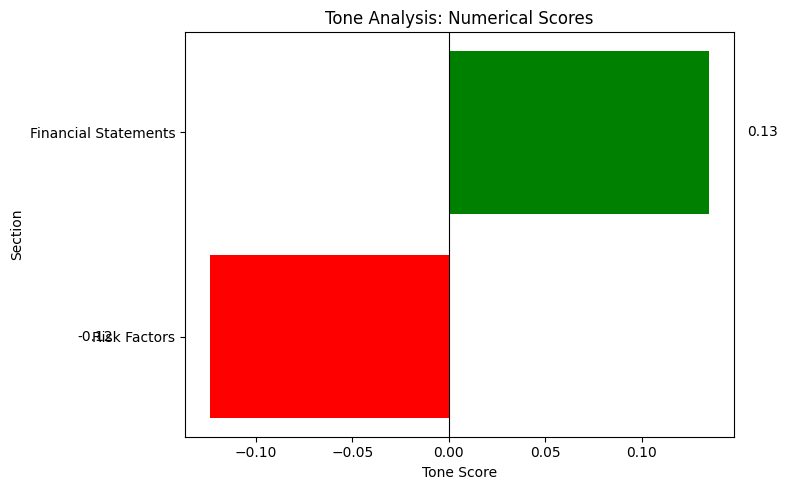


--- Sentiment Summaries ---

**Risk Factors:**
Risk Factors section shows a predominantly neutral sentiment, but with a noticeable trend towards negative, highlighting operational and societal risks.
----------------------------------------

**Financial Statements:**
Mostly neutral, but with some negative sentiment due to discussion of impairment losses and financial risks.
----------------------------------------
--- Sentiment Details ---
Section: Risk Factors

Text: Neutral.
Explanation: This is a table of contents-like section of a report, listing topics and page numbers. It presents factual information without expressing any positive or negative sentiment..


Text: Neutral.
Explanation: The text describes the company's activities and customer base without expressing strong positive or negative sentiments about the company's financial health or future prospects..


Text: Neutral.
Explanation: This excerpt presents factual financial data (capitalization table, debt figures) and refe

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Sample Data (Replace with your actual data)
numerical_tone_scores = {
    "Risk Factors": -0.12385696172714233,
    "Financial Statements": 0.13481706380844116
}

sentiment_summaries = {
    "Risk Factors": "Risk Factors section shows a predominantly neutral sentiment, but with a noticeable trend towards negative, highlighting operational and societal risks.",
    "Financial Statements": "Mostly neutral, but with some negative sentiment due to discussion of impairment losses and financial risks."
}


# 1. Visualizing Numerical Tone Scores - Diverging Bar Chart
def visualize_numerical_tone(tone_scores):
    """Visualizes numerical tone scores using a diverging bar chart."""

    sections = list(tone_scores.keys())
    scores = list(tone_scores.values())

    # Create a diverging bar chart
    plt.figure(figsize=(8, 5))
    colors = ['red' if score < 0 else 'green' for score in scores]  # Color-code based on sentiment

    plt.barh(sections, scores, color=colors)
    plt.axvline(0, color='black', linewidth=0.8)  # Center line for neutrality
    plt.xlabel("Tone Score")
    plt.ylabel("Section")
    plt.title("Tone Analysis: Numerical Scores")

    # Add score labels
    for i, score in enumerate(scores):
        plt.text(score + (0.02 if score >= 0 else -0.05), i, f"{score:.2f}", va='center', ha='left' if score >= 0 else 'right', color='black')

    plt.tight_layout()
    plt.show()


# 2. Visualizing Textual Sentiment Summaries (Simple Text Display)
def visualize_textual_summaries(summaries):
    """Visualizes textual summaries using formatted text output."""

    print("\n--- Sentiment Summaries ---")
    for section, summary in summaries.items():
        print(f"\n**{section}:**")
        print(summary)
        print("-" * 40)  # Separator


# 3. Combined Visualization (Simple Text with Numerical Chart)
def visualize_combined(tone_scores, summaries):
    """Combines numerical and textual visualizations."""

    visualize_numerical_tone(embedding_tone_results)
    visualize_textual_summaries(summaries)


# --- Main Execution ---

visualize_combined(numerical_tone_scores, sentiment_summaries)


# --- Example of a more advanced visualization using matplotlib's gridspec ---
# (This is more complex and might be better suited for a dashboard library like Dash or Plotly)
def visualize_combined_advanced(tone_scores, summaries):
    """Combines numerical and textual visualizations using matplotlib gridspec."""

    import matplotlib.gridspec as gridspec

    fig = plt.figure(figsize=(12, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])

    # Numerical Tone Scores (Diverging Bar Chart)
    ax1 = plt.Subplot(fig, gs[0])
    fig.add_subplot(ax1)

    sections = list(tone_scores.keys())
    scores = list(tone_scores.values())
    colors = ['red' if score < 0 else 'green' for score in scores]

    ax1.barh(sections, scores, color=colors)
    ax1.axvline(0, color='black', linewidth=0.8)
    ax1.set_xlabel("Tone Score")
    ax1.set_ylabel("Section")
    ax1.set_title("Tone Analysis: Numerical Scores")

    for i, score in enumerate(scores):
        ax1.text(score + (0.02 if score >= 0 else -0.05), i, f"{score:.2f}", va='center', ha='left' if score >= 0 else 'right', color='black')

    # Textual Summaries
    ax2 = plt.Subplot(fig, gs[1])
    fig.add_subplot(ax2)

    ax2.axis('off')  # Turn off axes for text display
    text_y = 0.9
    for section, summary in summaries.items():
        ax2.text(0.05, text_y, f"**{section}:**\n{summary}", va='top', ha='left', fontsize=10)
        text_y -= 0.4  # Adjust vertical spacing

    fig.suptitle("Combined Tone and Sentiment Analysis", fontsize=16)
    plt.tight_layout()
    plt.show()

print("--- Sentiment Details ---")
for key, value_list in cleaned_sentiment_results.items():
    print(f"Section: {key}\n")
    for item in value_list:
        parts = item.split("\nExplanation:")
        if len(parts) == 2:
            text_part, explanation = parts
            print(f"Text: {text_part.strip()}.")
            print(f"Explanation: {explanation.strip()}.")
        else:
            print(f"Text: {item.strip()}.")
        print("\n")
    print("-" * 40 + "\n")